In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- CONFIG ---
DATA_DIR = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train"
TEST_DATA_DIR = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test"
BATCH_SIZE = 32
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [2]:
# Load all images from the train folder
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Get indices for stratified split
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    random_state=42,
    stratify=full_dataset.targets
)

# Create Subsets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total images found: {len(full_dataset)}")
print(f"Training on: {len(train_dataset)} | Validating on: {len(val_dataset)}")

Total images found: 322498
Training on: 257998 | Validating on: 64500


In [3]:
# Using ShuffleNetV2 0.5x
model = models.shufflenet_v2_x0_5(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 2)  # Binary classification
model = model.to(DEVICE)

# Standard Loss (No Class Weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler(device='cuda') if torch.cuda.is_available() else torch.amp.GradScaler(device='cpu')

Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


100%|██████████| 5.28M/5.28M [00:00<00:00, 69.5MB/s]


In [4]:
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct/total)

    # --- VALIDATION PHASE ---
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    history["loss"].append(running_loss/len(train_loader))
    history["accuracy"].append(correct/total)
    history["val_loss"].append(v_loss/len(val_loader))
    history["val_accuracy"].append(v_correct/v_total)
    
    print(f"Epoch {epoch+1} -> Train Acc: {correct/total:.4f}, Val Acc: {v_correct/v_total:.4f}")

torch.save(model.state_dict(), "shufflenetv2_skin_cancer.pth")

Epoch 1/20: 100%|██████████| 8063/8063 [15:52<00:00,  8.47it/s, acc=0.998, loss=0.00835] 


Epoch 1 -> Train Acc: 0.9978, Val Acc: 0.9995


Epoch 2/20: 100%|██████████| 8063/8063 [08:28<00:00, 15.87it/s, acc=1, loss=6.25e-6]     


Epoch 2 -> Train Acc: 0.9996, Val Acc: 0.9999


Epoch 3/20: 100%|██████████| 8063/8063 [09:01<00:00, 14.88it/s, acc=1, loss=8.94e-7] 


...

Epoch 18 -> Train Acc: 0.9999, Val Acc: 0.9999


Epoch 19/20: 100%|██████████| 8063/8063 [10:46<00:00, 12.47it/s, acc=1, loss=0]       


Epoch 19 -> Train Acc: 0.9999, Val Acc: 0.9992


Epoch 20/20: 100%|██████████| 8063/8063 [10:41<00:00, 12.58it/s, acc=1, loss=1.03e-5] 


Epoch 20 -> Train Acc: 0.9999, Val Acc: 0.9996


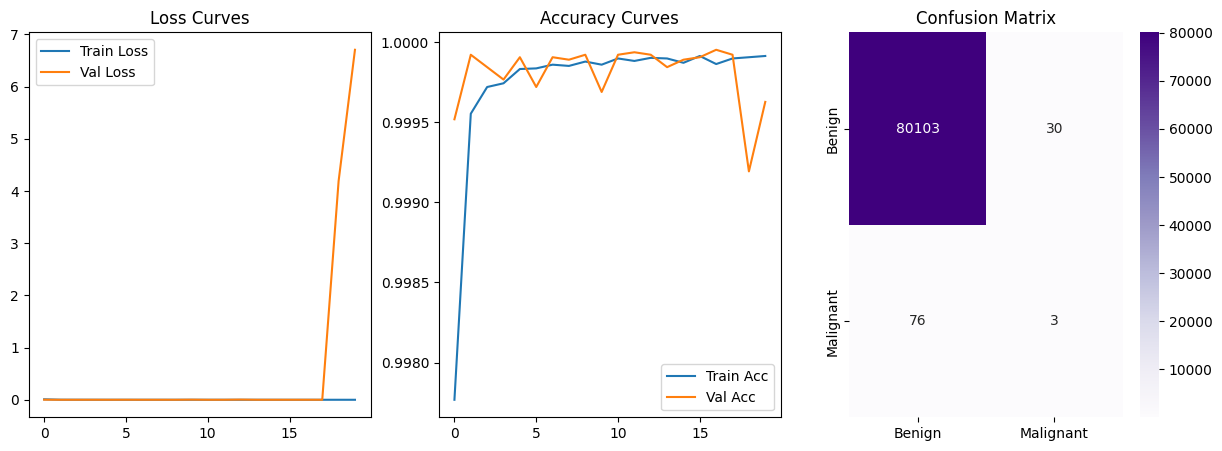


Test Set ROC-AUC: 0.5391
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     80133
   Malignant       0.09      0.04      0.05        79

    accuracy                           1.00     80212
   macro avg       0.54      0.52      0.53     80212
weighted avg       1.00      1.00      1.00     80212



In [5]:
# Load Test Data
test_dataset = datasets.ImageFolder(TEST_DATA_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
y_probs, y_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_probs.extend(probs)
        y_true.extend(labels.numpy())

y_probs, y_true = np.array(y_probs), np.array(y_true)
y_pred = (y_probs > 0.5).astype(int)

# --- VISUALS ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history["loss"], label='Train Loss')
plt.plot(history["val_loss"], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["accuracy"], label='Train Acc')
plt.plot(history["val_accuracy"], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.show()

print(f"\nTest Set ROC-AUC: {auc(roc_curve(y_true, y_probs)[0], roc_curve(y_true, y_probs)[1]):.4f}")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))